In [1]:
import pandas as pd

# 데이터 생성 (50개 샘플)
data = {
    '연소득(백만)': [45, 30, 80, 55, 120, 25, 60, 95, 35, 70, 42, 58, 110, 28, 75, 85, 48, 32, 130, 52, 65, 40, 90, 38, 72, 45, 55, 105, 30, 68, 82, 47, 53, 115, 27, 78, 88, 50, 34, 140, 55, 62, 41, 92, 39, 74, 46, 56, 100, 29],
    '신용점수': [700, 620, 780, 650, 820, 580, 710, 750, 600, 720, 680, 690, 800, 590, 740, 760, 670, 610, 840, 660, 700, 640, 770, 620, 730, 685, 695, 790, 595, 715, 765, 675, 665, 810, 585, 745, 775, 655, 615, 850, 670, 705, 630, 785, 625, 735, 680, 700, 795, 600],
    '부채비율(%)': [20, 45, 10, 30, 5, 55, 15, 12, 40, 18, 25, 22, 8, 50, 14, 11, 28, 42, 4, 32, 17, 35, 9, 38, 13, 21, 24, 7, 48, 16, 12, 26, 31, 6, 52, 15, 10, 29, 43, 3, 23, 18, 36, 11, 39, 14, 25, 20, 9, 47],
    '대출승인': [1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    '승인금액(백만)': [20, 0, 50, 25, 80, 0, 30, 60, 0, 45, 22, 28, 70, 0, 40, 55, 0, 0, 90, 25, 35, 0, 65, 0, 45, 25, 30, 75, 0, 40, 55, 24, 0, 85, 0, 50, 60, 28, 0, 100, 30, 35, 0, 65, 0, 48, 26, 32, 70, 0]
}

df = pd.DataFrame(data)

In [2]:
# 1. 샘플이 몇개인지 50
# 2. 샘플 당 피처가 몇 개인지 6
# 3. 대출 승인 여부의 모델을 만든다면 분류? 회귀? 분류
# 4. 대출 금액을 예상하는 모델을 만든다면 분휴? 회귀? 회귀
# 5. 만약 회귀라면 어떤 모델을 선택해야 하는지 다중, 다항
# 6. 만약 분류라면 어떤 모델을 선택해야 하나? 로지스틱 회귀

# 위에서 분석하면 EDA 탐색 후 결측치나 이상치를 전략
# 이것저것 다 해보면서 최적의 답을 찾아냄

# 추가로 5번과 6번에서 언급한 모델은 데이터를 선형으로 봐서 공식을 만들겠다
# 이상치의 영향이 클 수 있고 피처의 데이터를 선형으로 공식을 만드는 것이 아닌 if문으로 트리를 만드는 비선형 데이터로 보고 모델 만들기
# 피처를 보고 if문으로 트리를 만드는 모델을 결정트리라 함
# 결정트리는 비선형 데이터이고, 회귀와 분류 모두 다 가능

# 어제 했던 당뇨병 문제를 결정트리로 시도해보면 차이가 있을거임
# 평가지표가 더 높으면 당뇨병은 로지스틱 회귀와 결정트리중에 어떤 것이 더 맞는 것인지 확인 가능
#

In [3]:
# 순서 데이터로드 > 결측치 > EDA 탐색 > 데이터셋 > 모델 선택 > 학습 > 평가
# 주제는 연소득과 신용점수와 부채비율 피처로 승인여부 판단 모델

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# X, y 선택하고 데이터셋 나누기
X = df[['연소득(백만)', '신용점수', '부채비율(%)']]
print(X.shape)
y = df['대출승인']
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

(50, 3)
(50,)


In [6]:
# 결정트리 그려보기
#                        혈당 : 126?
#                          /       \
#                         yes      no
#                       당뇨임    BMI > 30?
#                                   /     \
#                                  yes     no
#                                당뇨임       정상)

# 용어
# Root Node        시작점, Depth    3, left Node 최종결과
# 주의 : 각 노드에는 여러 개의 샘플이 같이 있다.
                        

In [7]:
# 모델 선택
# 비선형모델인 결정트리 모델을 선택
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier( #파라미터..
        #트리의 최대 깊이, 중요한 파라미터
        #피처와 샘플데이터에 비해서 너무 깊으면 과적합
        #3개부터 10까지 조절하면서 ..
        max_depth = 3,
        #리프노드가 가져야 하는 최소 샘플 수 *중요한 파라미터
        #샘플 데이터가 많으면 5부터 차례대로 합니다
        min_samples_leaf = 5, # 5개의 샘플로 분류, 회귀 결과값
        
        # 불순도 계산 방식 - 노드에 샘플[승인4, 비승인8]
        criterion = 'gini'
        )

In [8]:
clf = model.fit(X_train, y_train)

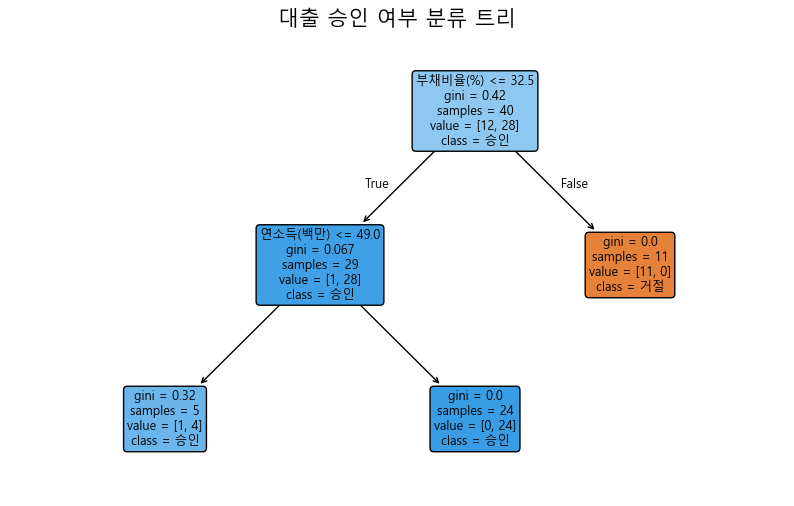

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 분류 모델 시각화
plt.figure(figsize=(10, 6))  # 크기를 15,10에서 10,6으로 줄임
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['거절', '승인'], 
          filled=True, 
          rounded=True, 
          fontsize=9)  # 글자 크기를 조절하여 가독성 향상
plt.title("대출 승인 여부 분류 트리", fontsize=15)
plt.show()

In [ ]:
# 위쪽 트리가 한쪽으로 치우쳤다 결론을 내려봤다 -test-

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier( #파라미터..
        #트리의 최대 깊이, 중요한 파라미터
        #피처와 샘플데이터에 비해서 너무 깊으면 과적합
        #3개부터 10까지 조절하면서 ..
        max_depth = 3,
        #리프노드가 가져야 하는 최소 샘플 수 *중요한 파라미터
        #샘플 데이터가 많으면 5부터 차례대로 합니다
        min_samples_leaf = 5, # 5개의 샘플로 분류, 회귀 결과값
        
        # 불순도 계산 방식 - 노드에 샘플[승인4, 비승인8]
        criterion = 'gini',
        class_weight = 'balanced' # 학습데이터가 정규분포형태라면 좋음
        )

In [12]:
clf = model.fit(X_train, y_train)

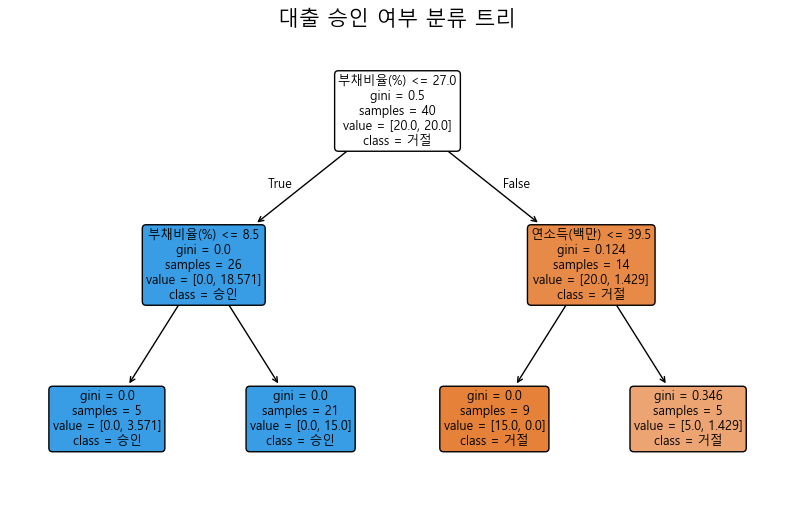

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 분류 모델 시각화
plt.figure(figsize=(10, 6))  # 크기를 15,10에서 10,6으로 줄임
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['거절', '승인'], 
          filled=True, 
          rounded=True, 
          fontsize=9)  # 글자 크기를 조절하여 가독성 향상
plt.title("대출 승인 여부 분류 트리", fontsize=15)
plt.show()

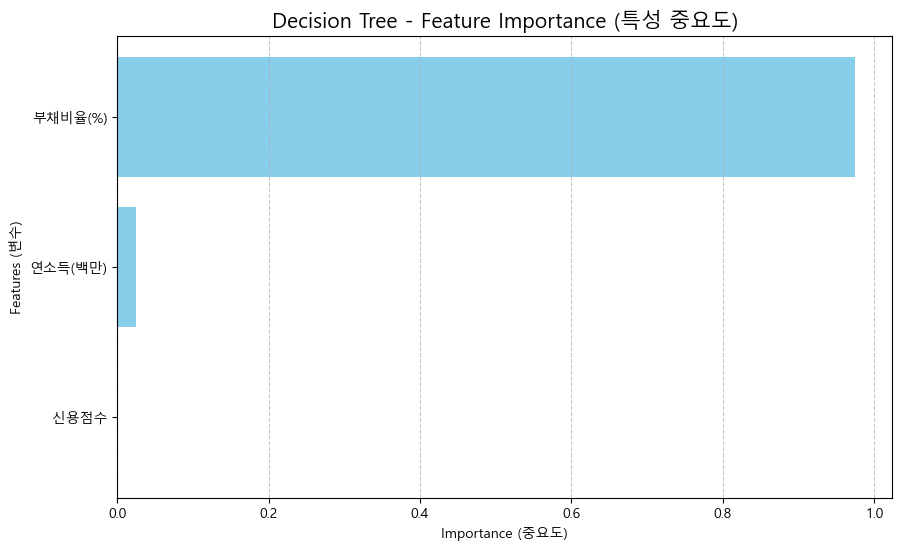

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 중요도 데이터 추출
# clf는 이미 학습된 DecisionTreeClassifier 또는 DecisionTreeRegressor 객체여야 합니다.
importances = model.feature_importances_
feature_names = X.columns

# 2. 중요도 순으로 정렬 (보기 좋게 시각화하기 위함)
indices = np.argsort(importances)

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.title("Decision Tree - Feature Importance (특성 중요도)", fontsize=15)
plt.xlabel("Importance (중요도)")
plt.ylabel("Features (변수)")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [15]:
# 중요도를 보고서 개발자가 도메인에서 판단하는 중요 피처가 모델이 얼마나 인지 했는지 판단해서 샘플의 결과값을 기준으로 발란스 맞게 추가
# 또는 전처리, 이상치 처리, 샘플의 데이터를 더 추가해서 정상분포를 만들기
# 가장 잘 먹히는 전략은 전처리와 이상치도 중요하지만 샘플의 정확도가 젤 중요
# 샘플의 품질이란 좋은 피처, 예측값 피처의 균형, 승인과 거절피처의 비율이 7:3 이라면 과적합의 원인이 될 수 있음
# 특히 이런 건 분류모델에서 매우 중요하기에 대게 예측하려는 피처를 1:1로 많이 함

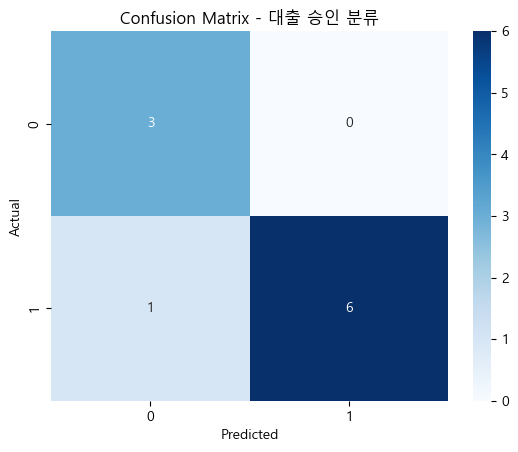

Accuracy: 0.9
Precision: 1.0
Recall: 0.8571428571428571
F1-score: 0.9230769230769231


In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)

# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - 대출 승인 분류')
plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

In [17]:
# 과연 현실 데이터를 생각할 때 트리의 모양은 밸런스를 맞춰야 할까
# 금융사기탐지 : 사기 1%, 정상 99%
# 질병 예측 : 환자   정상/ 정상이 더 높을듯
# 결정트리가 밸런스를 꼭 맞춰야 하는지에 대한 질문은 피처의 특징을 고려해야함
# 현실 데이터는 밸런스가 맞지 않는  경우가 많음
# 모델 파라미터를 만들 때 밸런스 옵션을 사용하지 않는게 성능이 좋을 수 있음 